# 5주차 실습 — 퍼셉트론: 학습 규칙, 논리 게이트, 그리고 MLP로의 확장 (2026 개정판)

**기계학습특론** · 최승호 (jcn99250@naver.com)

이번 실습은 다섯 부분으로 구성됩니다.

| 파트 | 내용 | 라이브러리 |
|---|---|---|
| 1 | Rosenblatt 퍼셉트론 학습 규칙 직접 구현, 수렴 정리 실험 (마진 vs. 갱신 횟수) | NumPy |
| 2 | 논리 게이트(AND/OR/XOR)와 선형 분리 가능성 | NumPy |
| 3 | scikit-learn `Perceptron`으로 필기체 숫자 분류 (기존 실습 갱신) | scikit-learn 1.8 |
| 4 | PyTorch로 퍼셉트론(=로지스틱 회귀)과 2층 MLP 구현, XOR 해결 | PyTorch 2.x |
| 5 | 트랜스포머 블록 안의 "퍼셉트론" 찾기 — FFN은 2층 MLP다 | PyTorch |

> 실행 환경: Python ≥ 3.10, `pip install numpy scikit-learn matplotlib torch`. GPU 불필요.


In [1]:
import numpy as np, matplotlib.pyplot as plt, torch, sklearn
print('numpy', np.__version__, '| torch', torch.__version__, '| sklearn', sklearn.__version__)
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)

# 한글 그래프 폰트 설정 (Windows: Malgun Gothic, macOS: AppleGothic, Colab: 아래 주석 참고)
import matplotlib
from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR', 'Noto Sans CJK SC', 'Noto Sans CJK JP']:
    if _f in _avail:
        matplotlib.rcParams['font.family'] = _f; break
matplotlib.rcParams['axes.unicode_minus'] = False
# Colab: !apt-get -qq install fonts-nanum && 런타임 재시작 후 위 셀 재실행
print('그래프 폰트:', matplotlib.rcParams['font.family'])

numpy 2.4.4 | torch 2.14.0+cu130 | sklearn 1.8.0
그래프 폰트: ['Noto Sans CJK JP']


## 파트 1. Rosenblatt 퍼셉트론 학습 규칙 (1958)

퍼셉트론은 특징 벡터 $\mathbf{x}\in\mathbb{R}^d$ (바이어스 성분 $x_0=1$ 포함)에 대해

$$\hat y = \operatorname{sgn}(\mathbf{w}^\top \mathbf{x}),\qquad y\in\{-1,+1\}$$

로 예측하고, **오분류된 샘플에 대해서만** 다음 규칙으로 가중치를 갱신합니다.

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\, y_i\, \mathbf{x}_i \quad (\text{if } y_i \mathbf{w}^\top\mathbf{x}_i \le 0)$$

이 규칙은 손실 $L(\mathbf{w}) = \sum_{i\in\mathcal{M}} -y_i\mathbf{w}^\top\mathbf{x}_i$ (오분류 집합 $\mathcal{M}$)에 대한 확률적 경사 하강과 동일합니다.

**퍼셉트론 수렴 정리 (Novikoff, 1962).** 데이터가 마진 $\gamma>0$으로 선형 분리 가능하고 $\|\mathbf{x}_i\|\le R$이면, 갱신 횟수는 $\le (R/\gamma)^2$ 입니다. 아래에서 마진을 바꿔 가며 이를 실험으로 확인합니다.


갱신 횟수 = 4, 에폭 수 = 2, 최종 훈련 오류 = 0


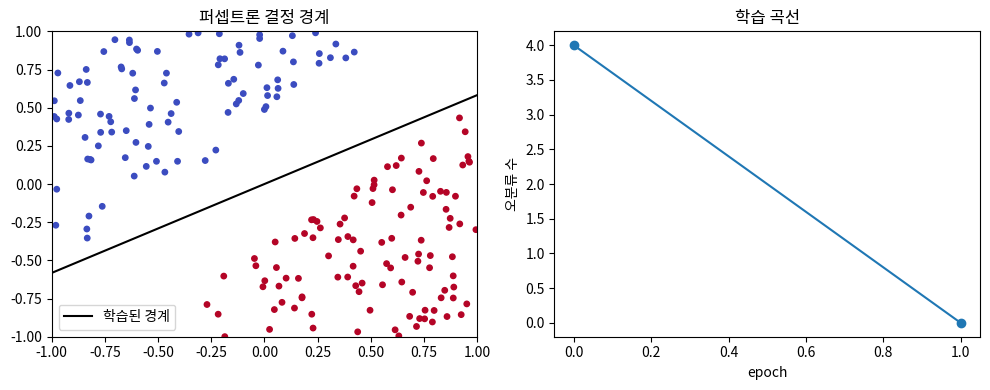

In [2]:
def perceptron_train(X, y, lr=1.0, max_epochs=1000):
    """Rosenblatt 학습 규칙. X: (N,d) (바이어스 열 포함), y: {-1,+1}. 반환: w, 갱신 횟수, 에폭별 오류 수"""
    w = np.zeros(X.shape[1]); n_updates = 0; history = []
    for epoch in range(max_epochs):
        errors = 0
        for xi, yi in zip(X, y):
            if yi * (w @ xi) <= 0:          # 오분류(또는 경계 위)일 때만 갱신
                w += lr * yi * xi; n_updates += 1; errors += 1
        history.append(errors)
        if errors == 0: break               # 모든 샘플이 올바르게 분류되면 종료
    return w, n_updates, history

def make_separable(n=200, margin=0.5, d=2, seed=0):
    """진짜 분리 초평면 w*로부터 마진 이상 떨어진 점만 남겨 선형 분리 가능 데이터 생성"""
    rng = np.random.default_rng(seed)
    w_star = rng.normal(size=d); w_star /= np.linalg.norm(w_star)
    X = rng.uniform(-1, 1, size=(4*n, d))
    s = X @ w_star
    keep = np.abs(s) >= margin
    X, s = X[keep][:n], s[keep][:n]
    y = np.where(s > 0, 1, -1)
    Xb = np.hstack([np.ones((len(X),1)), X])   # x0 = 1 (바이어스)
    return Xb, y, w_star

Xb, y, w_star = make_separable(margin=0.3)
w, n_upd, hist = perceptron_train(Xb, y)
print(f'갱신 횟수 = {n_upd}, 에폭 수 = {len(hist)}, 최종 훈련 오류 = {hist[-1]}')

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].scatter(Xb[:,1], Xb[:,2], c=y, cmap='coolwarm', s=15)
xs = np.linspace(-1,1,2)
ax[0].plot(xs, -(w[0] + w[1]*xs)/w[2], 'k-', label='학습된 경계')
ax[0].set_title('퍼셉트론 결정 경계'); ax[0].set_xlim(-1,1); ax[0].set_ylim(-1,1); ax[0].legend()
ax[1].plot(hist, 'o-'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('오분류 수'); ax[1].set_title('학습 곡선')
plt.tight_layout(); plt.show()

### 실험: 마진 $\gamma$가 작아질수록 갱신 횟수가 $(R/\gamma)^2$ 스케일로 증가하는가?

  margin      평균 갱신횟수     (R/γ)^2 상한
   0.400          3.4           18.7
   0.200          4.8           75.0
   0.100          7.6          300.0
   0.050          8.0         1200.0
   0.025         12.4         4800.0


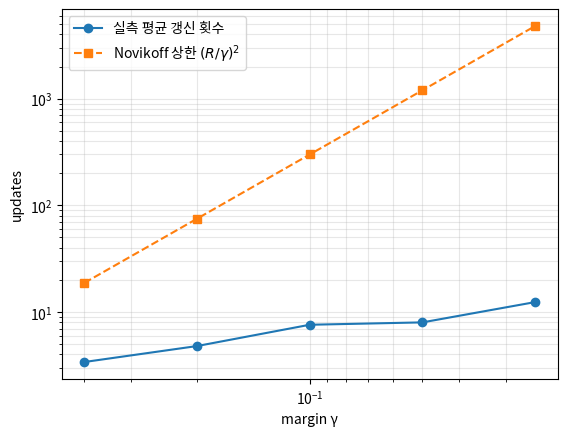

In [3]:
margins = [0.4, 0.2, 0.1, 0.05, 0.025]
rows = []
for g in margins:
    ups = []
    for seed in range(10):
        Xb, y, _ = make_separable(margin=g, seed=seed)
        _, n_upd, _ = perceptron_train(Xb, y, max_epochs=5000)
        ups.append(n_upd)
    R = np.sqrt(3.0)   # |x0|=1, x1,x2 ∈[-1,1] → ||x|| ≤ sqrt(3)
    rows.append((g, np.mean(ups), (R/g)**2))
print(f"{'margin':>8} {'평균 갱신횟수':>12} {'(R/γ)^2 상한':>14}")
for g, m, b in rows: print(f'{g:8.3f} {m:12.1f} {b:14.1f}')

plt.loglog([r[0] for r in rows], [r[1] for r in rows], 'o-', label='실측 평균 갱신 횟수')
plt.loglog([r[0] for r in rows], [r[2] for r in rows], 's--', label='Novikoff 상한 $(R/\\gamma)^2$')
plt.gca().invert_xaxis(); plt.xlabel('margin γ'); plt.ylabel('updates'); plt.legend(); plt.grid(True, which='both', alpha=.3)
plt.show()

**해석.** 실측 갱신 횟수는 항상 상한 아래에 있으며, 마진이 절반이 되면 대략 4배 가까이 증가하는 $1/\gamma^2$ 경향을 보입니다. 상한은 *최악의 샘플 순서*에 대한 것이므로 실측치는 보통 훨씬 작습니다.

> **심화 (대학원):** 퍼셉트론은 분리 초평면을 *아무거나* 찾지만, 로지스틱 손실로 경사 하강을 무한히 돌리면 $\mathbf{w}/\|\mathbf{w}\|$ 가 **최대 마진(hard-margin SVM) 방향으로 수렴**합니다 (Soudry et al., JMLR 2018, "implicit bias"). 최근 연구는 다중 클래스(NeurIPS 2024)와 Muon·스펙트럴 디센트(2025, 스펙트럴 노름 기준 최대 마진)로 확장되었습니다. 강의 슬라이드 참고.


## 파트 2. 논리 게이트와 선형 분리 가능성

입력 $(x_1,x_2)\in\{0,1\}^2$ 에 대해 AND, OR, XOR 을 퍼셉트론으로 학습시켜 봅니다. 활성화 함수는 계단 함수이며 출력은 $\{0,1\}$ 로 표현합니다.


AND: w = [-4.  3.  2.], 갱신 18회, 훈련 정확도 = 1.00
OR: w = [-1.  2.  2.], 갱신 9회, 훈련 정확도 = 1.00
XOR: w = [0. 0. 0.], 갱신 400회, 훈련 정확도 = 0.50


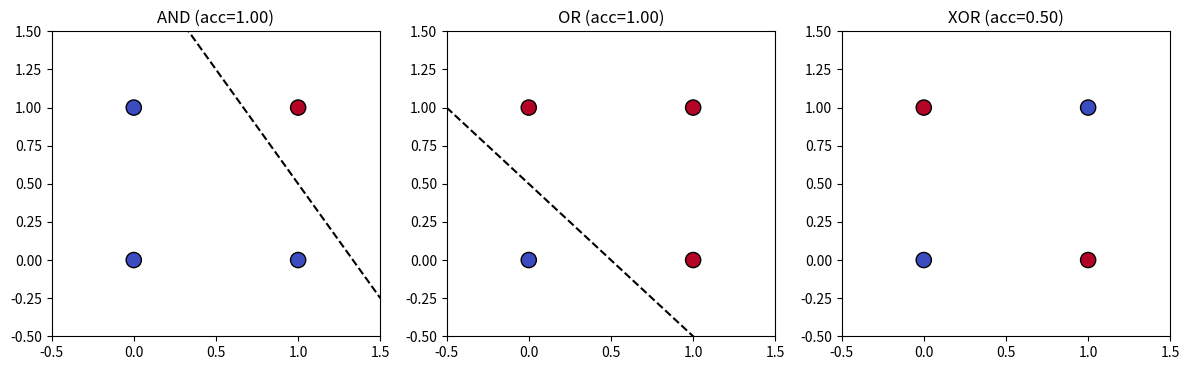

In [4]:
X_gate = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Xb_gate = np.hstack([np.ones((4,1)), X_gate])
gates = {'AND': np.array([0,0,0,1]), 'OR': np.array([0,1,1,1]), 'XOR': np.array([0,1,1,0])}

fig, axes = plt.subplots(1, 3, figsize=(12,3.8))
for ax, (name, t) in zip(axes, gates.items()):
    y_pm = np.where(t==1, 1, -1)
    w, n_upd, hist = perceptron_train(Xb_gate, y_pm, max_epochs=100)
    pred = (Xb_gate @ w > 0).astype(int)
    print(f'{name}: w = {np.round(w,2)}, 갱신 {n_upd}회, 훈련 정확도 = {np.mean(pred==t):.2f}')
    ax.scatter(X_gate[:,0], X_gate[:,1], c=t, cmap='coolwarm', s=120, edgecolor='k')
    if abs(w[2]) > 1e-9:
        xs = np.linspace(-.5,1.5,2); ax.plot(xs, -(w[0]+w[1]*xs)/w[2], 'k--')
    ax.set_title(f'{name} (acc={np.mean(pred==t):.2f})'); ax.set_xlim(-.5,1.5); ax.set_ylim(-.5,1.5)
plt.tight_layout(); plt.show()

**결과.** AND/OR 은 몇 번의 갱신으로 수렴하지만 XOR 은 `max_epochs` 를 다 써도 정확도가 0.5~0.75 를 넘지 못합니다. 이는 알고리즘의 문제가 아니라 **표현력의 한계**입니다 (Minsky & Papert, 1969) — 단일 초평면으로는 XOR 의 두 클래스를 나눌 수 없습니다. 해결책은 파트 4에서 다룹니다.


## 파트 3. scikit-learn `Perceptron` — 필기체 숫자 분류 (기존 실습 갱신)

sklearn 의 `Perceptron` 은 다중 클래스에 대해 자동으로 one-vs-rest 를 수행합니다. 기존 실습 코드를 최신 API 관례(`ConfusionMatrixDisplay`, `StandardScaler` 파이프라인)로 정리했습니다.


테스트 정확도 = 0.94
              precision    recall  f1-score   support

           0      0.957     0.978     0.967        45
           1      0.911     0.891     0.901        46
           2      0.977     0.977     0.977        44
           3      0.938     0.978     0.957        46
           4      0.977     0.933     0.955        45
           5      0.898     0.957     0.926        46
           6      0.936     0.978     0.957        45
           7      0.977     0.933     0.955        45
           8      0.878     0.837     0.857        43
           9      0.955     0.933     0.944        45

    accuracy                          0.940       450
   macro avg      0.940     0.940     0.940       450
weighted avg      0.940     0.940     0.940       450



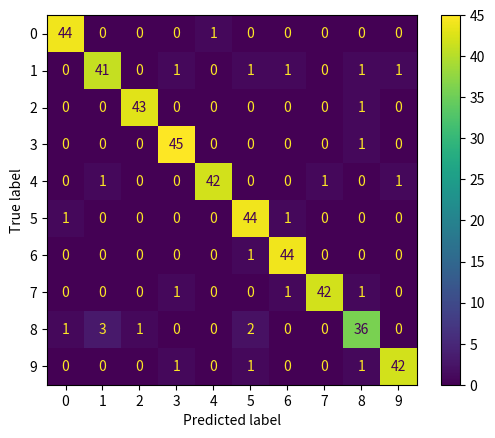

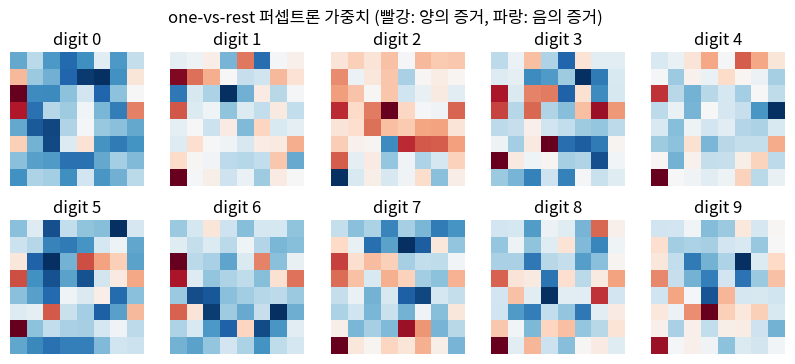

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)

clf = make_pipeline(StandardScaler(), Perceptron(tol=1e-3, random_state=0))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('테스트 정확도 =', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred); plt.show()

# 가중치 벡터를 8x8 이미지로 시각화: 각 클래스 퍼셉트론이 "어떤 픽셀"에 반응하는지
W = clf[-1].coef_
fig, axes = plt.subplots(2,5, figsize=(10,4))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(W[k].reshape(8,8), cmap='RdBu'); ax.set_title(f'digit {k}'); ax.axis('off')
plt.suptitle('one-vs-rest 퍼셉트론 가중치 (빨강: 양의 증거, 파랑: 음의 증거)'); plt.show()

## 파트 4. PyTorch — 퍼셉트론(로지스틱 회귀)과 2층 MLP

* **활성화를 시그모이드로 바꾼 퍼셉트론 = 로지스틱 회귀** 입니다. `nn.Linear(2,1)` + `BCEWithLogitsLoss` 로 구현하면 손실이 볼록(convex)이라 경사 하강이 전역 최적에 도달합니다.
* **은닉층 하나를 추가한 2층 MLP** 는 XOR 을 풀 수 있습니다 (은닉 뉴런 2개면 충분).
* 최신 관례: `torch.optim.AdamW`, `torch.nn.functional`, 명시적 시드, 배치 전체를 텐서로 처리.


In [6]:
import torch.nn as nn, torch.nn.functional as F

Xt = torch.tensor(X_gate, dtype=torch.float32)
yt_xor = torch.tensor(gates['XOR'], dtype=torch.float32).unsqueeze(1)

def train_torch(model, X, y, epochs=2000, lr=0.1, wd=0.0, log_every=500):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    for ep in range(1, epochs+1):
        logits = model(X)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        if ep % log_every == 0 or ep == 1:
            acc = ((logits > 0).float() == y).float().mean().item()
            print(f'  epoch {ep:5d}  loss={loss.item():.4f}  acc={acc:.2f}')
    return model

torch.manual_seed(0)
print('[1] 단층 퍼셉트론 (nn.Linear 2→1) on XOR')
single = nn.Linear(2, 1)
train_torch(single, Xt, yt_xor)

torch.manual_seed(0)
print('\n[2] 2층 MLP (2→2→1, tanh) on XOR')
mlp = nn.Sequential(nn.Linear(2, 2), nn.Tanh(), nn.Linear(2, 1))
train_torch(mlp, Xt, yt_xor)

[1] 단층 퍼셉트론 (nn.Linear 2→1) on XOR


  epoch     1  loss=0.7168  acc=0.50


  epoch   500  loss=0.6931  acc=0.75


  epoch  1000  loss=0.6931  acc=0.50
  epoch  1500  loss=0.6931  acc=0.75


  epoch  2000  loss=0.6931  acc=0.50

[2] 2층 MLP (2→2→1, tanh) on XOR
  epoch     1  loss=0.7152  acc=0.25


  epoch   500  loss=0.0009  acc=1.00


  epoch  1000  loss=0.0003  acc=1.00


  epoch  1500  loss=0.0001  acc=1.00


  epoch  2000  loss=0.0001  acc=1.00


Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Tanh()
  (2): Linear(in_features=2, out_features=1, bias=True)
)

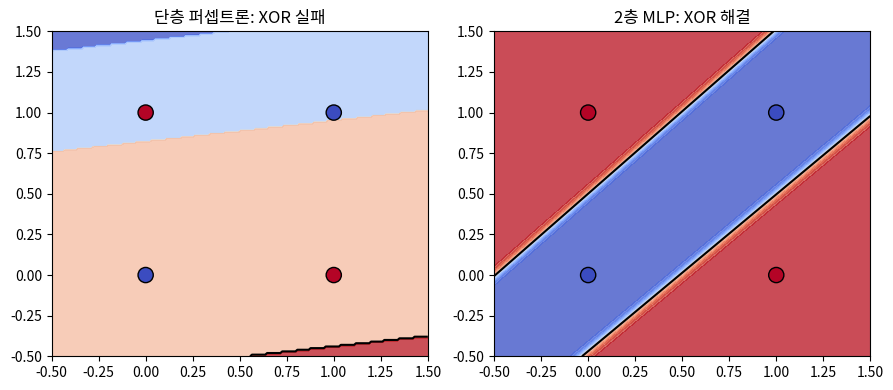

은닉층 출력 h(x):
[[-0.99 -0.98]
 [ 0.99 -1.  ]
 [-1.    0.99]
 [-0.99 -0.99]]


In [7]:
def plot_boundary(model, title, ax):
    xx, yy = np.meshgrid(np.linspace(-.5,1.5,200), np.linspace(-.5,1.5,200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad(): zz = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=20, cmap='coolwarm', alpha=.8)
    ax.contour(xx, yy, zz, levels=[0.5], colors='k')
    ax.scatter(X_gate[:,0], X_gate[:,1], c=gates['XOR'], cmap='coolwarm', s=120, edgecolor='k')
    ax.set_title(title)

fig, axes = plt.subplots(1,2, figsize=(9,4))
plot_boundary(single, '단층 퍼셉트론: XOR 실패', axes[0])
plot_boundary(mlp, '2층 MLP: XOR 해결', axes[1])
plt.tight_layout(); plt.show()

# 은닉층이 만든 새로운 특징 공간에서는 XOR가 선형 분리 가능해진다
with torch.no_grad(): H = torch.tanh(mlp[0](Xt)).numpy()
print('은닉층 출력 h(x):'); print(np.round(H, 2))

**핵심 메시지.** 은닉층은 입력을 *새로운 좌표계* $\mathbf{h}=\phi(W_1\mathbf{x}+\mathbf{b}_1)$ 로 옮기고, 출력층은 그 공간에서 **다시 퍼셉트론**을 적용합니다. 위 `H` 출력에서 XOR 의 두 클래스가 선형 분리 가능하게 재배치된 것을 확인하세요. 이 "특징 학습 + 선형 분류기" 구조가 CNN·트랜스포머까지 이어지는 딥러닝의 기본 골격입니다.


### 4-b. PyTorch MLP 로 필기체 숫자 분류 — 파트 3의 선형 퍼셉트론과 비교

In [8]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)
Xtr = torch.tensor(sc.transform(X_train), dtype=torch.float32); ytr = torch.tensor(y_train)
Xte = torch.tensor(sc.transform(X_test),  dtype=torch.float32); yte = torch.tensor(y_test)

def fit_classifier(model, epochs=60, lr=1e-3, bs=64):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    n = len(Xtr)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            loss = F.cross_entropy(model(Xtr[idx]), ytr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        return (model(Xte).argmax(1) == yte).float().mean().item()

torch.manual_seed(0)
acc_lin = fit_classifier(nn.Linear(64, 10))                                   # 다중클래스 퍼셉트론(softmax 회귀)
torch.manual_seed(0)
acc_mlp = fit_classifier(nn.Sequential(nn.Linear(64,128), nn.GELU(), nn.Dropout(0.1), nn.Linear(128,10)))
print(f'선형(softmax 퍼셉트론) 테스트 정확도 = {acc_lin:.4f}')
print(f'2층 MLP(GELU)      테스트 정확도 = {acc_mlp:.4f}')

선형(softmax 퍼셉트론) 테스트 정확도 = 0.9600
2층 MLP(GELU)      테스트 정확도 = 0.9711


## 파트 5. 트랜스포머 블록 안의 퍼셉트론

LLM 을 구성하는 트랜스포머 블록은 **어텐션**과 **FFN(feed-forward network)** 의 반복입니다. FFN 은 정확히 우리가 방금 만든 2층 MLP 이며 (`Linear → 활성화 → Linear`), GPT 계열 모델 파라미터의 약 2/3 가 여기에 있습니다. 아래에서 PyTorch 의 `TransformerEncoderLayer` 를 열어 확인합니다.


In [9]:
layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=256, batch_first=True)
print(layer)
n_ffn = sum(p.numel() for n,p in layer.named_parameters() if 'linear' in n)
n_all = sum(p.numel() for p in layer.parameters())
print(f'\nFFN(2층 MLP) 파라미터 비율 = {n_ffn/n_all:.1%}')

# 하나의 FFN 뉴런 = 하나의 퍼셉트론: w1·x + b1 → 활성화 → 출력 가중치 w2
x = torch.randn(1, 5, 64)                     # (batch, tokens, d_model)
h = F.relu(layer.linear1(x))                  # 256개의 "퍼셉트론"이 각 토큰에 대해 발화 여부 결정
print('활성화된 FFN 뉴런 비율(토큰별):', (h > 0).float().mean(dim=-1).squeeze().numpy().round(2))

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (linear1): Linear(in_features=64, out_features=256, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=256, out_features=64, bias=True)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

FFN(2층 MLP) 파라미터 비율 = 66.2%
활성화된 FFN 뉴런 비율(토큰별): [0.5  0.48 0.4  0.46 0.51]


**정리.**
1. 퍼셉트론 = 가중합 + 비선형 활성화. 학습 규칙은 오분류 샘플에 대한 SGD 이고, 분리 가능하면 $(R/\gamma)^2$ 회 이내에 수렴한다.
2. 단일 퍼셉트론은 선형 분리 가능한 문제(AND, OR)만 풀 수 있고 XOR 은 못 푼다.
3. 은닉층을 쌓으면(MLP) 표현력이 보편 근사(universal approximation)로 확장되고, 학습은 역전파로 한다.
4. 트랜스포머·LLM 의 FFN 은 2층 MLP 이며, 어텐션도 "학습된 가중합"이라는 점에서 퍼셉트론의 직계 후손이다.

**과제(선택).** (a) 파트 1에서 학습률 $\eta$ 를 바꿔도 갱신 횟수가 변하지 않는 이유를 수식으로 설명하시오. (b) 파트 4의 MLP 에 은닉 뉴런을 1개만 두면 XOR 을 풀 수 있는지 실험하고 이유를 설명하시오. (c) 파트 4-b 에서 은닉층 폭을 32, 128, 512 로 바꿔 정확도와 파라미터 수를 표로 정리하시오.
